In [ ]:
!pip install info-nce-pytorch

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
from pathlib import Path

import sys
sys.path.append('../../')

import phys_ml
import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

## contents

1&emsp;Autoencoder  
&emsp;1-1&emsp;trained on all vertices  
&emsp;&emsp;1-1-1&emsp;simple autoencoder  
&emsp;&emsp;1-1-2&emsp;contrastive autoencoder  
&emsp;1-2&emsp;trained on only 2 phases  
&emsp;&emsp;1-2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;1-2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;1-2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;1-2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;1-2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;1-2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;1-2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;1-2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;1-2-3-2&emsp;contrastive autoencoder  
&emsp;1-3&emsp;trained on only 1 phase  
&emsp;&emsp;1-3-1&emsp;SC-phase  
&emsp;&emsp;1-3-2&emsp;AFM-phase  
&emsp;&emsp;1-3-3&emsp;FM-phase  
&emsp;1-4&emsp;correlation  
&emsp;1-5&emsp;convergence  
2&emsp;Phase classifier  
&emsp;2-0&emsp;on real space  
&emsp;2-1&emsp;trained on all vertices  
&emsp;&emsp;2-1-1&emsp;simple autoencoder  
&emsp;&emsp;2-1-2&emsp;contrastive autoencoder  
&emsp;2-2&emsp;trained on only 2 phases  
&emsp;&emsp;2-2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;2-2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;2-2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;2-2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-3-2&emsp;contrastive autoencoder  
&emsp;2-3&emsp;trained on only 1 phase  
&emsp;&emsp;2-3-1&emsp;SC-phase  
&emsp;&emsp;2-3-2&emsp;AFM-phase  
&emsp;&emsp;2-3-3&emsp;FM-phase  

## slurm

In [3]:
# config
base_dir = '/gpfs/data/fs71925/shepp123/'

def create_slurm(version: str, model_wrapper: str = 'VertexWrapper24x6', model_name: str = 'AutoEncoderVertex', 
                 dataset: str = 'AutoEncoderVertex24x6Dataset', hidden_dims: list[int] = [128, 64, 32], 
                 sample_count_per_vertex: int = 24000, subset: float|int|None = None, subset_type: list[str]|str|None = None,
                 batch_size: int = 8192, qos: str = 'zen3_0512_a100x2', time: str = '24:00:00'):
    trainer_kwargs = {
        'config_name': 'confmod_auto_encoder.json', 
        'subconfig_name': 'AUTO_ENCODER_VERTEX_24X6', 
        'config_kwargs': {
            'path_train': base_dir + 'frgs_6d',
            'resume': 'run_results/' + version,
            'model_wrapper': model_wrapper,
            'model_name': model_name,
            'dataset': dataset,
            'hidden_dims': hidden_dims,
            'epochs': 25_000,
            'sample_count_per_vertex': sample_count_per_vertex, 
            'test_ratio': 0.2, 
            'subset': subset, 
            'subset_type': subset_type,
            'subset_shuffle': False, 
            'devices': 'auto', 
            'device_type': 'gpu', 
            'num_dataloader_workers': 16, 
            'batch_size': batch_size,
        }
    }
    slurm_options = slurm_generate.SlurmOptions(qos=qos, time=time)
    slurm_kwargs = {'project_name': 'vertex_24x6', 'pyenv_dir': base_dir + 'pyenv', 
                    'trainer': 'vertex.VertexTrainer24x6', 'slurm_options': slurm_options, 'trainer_kwargs': trainer_kwargs}
    slurm_generate.create(script_name='vertex_' + version, **slurm_kwargs)

In [4]:
# test run
create_slurm(version='vsc_test_ae', qos='zen3_0512_a100x2_devel', time='00:10:00')
create_slurm(version='vsc_test_cae', model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', 
             dataset='AutoEncoder24x6InfoNCEDataset', sample_count_per_vertex=6000, batch_size=2048, 
             qos='zen3_0512_a100x2_devel', time='00:10:00')

In [ ]:
# 1-1-1 trained on all vertices, simple autoencoder
create_slurm(version='1_1_1_32')

In [ ]:
# 1-1-2 trained on all vertices, contrastive autoencoder
create_slurm(version='1_1_2_32', model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', 
             dataset='AutoEncoder24x6InfoNCEDataset', sample_count_per_vertex=6000, batch_size=2048)

In [ ]:
# 1-2-1-1 exclude SC-phase, simple autoencoder
create_slurm(version='1_2_1_1_32', subset=0.8, subset_type=['afm', 'fm'])

In [ ]:
# 1-2-1-2 exclude SC-phase, contrastive autoencoder
create_slurm(version='1_2_1_2_32', model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', 
             dataset='AutoEncoder24x6InfoNCEDataset', sample_count_per_vertex=6000, subset=0.8, subset_type=['afm', 'fm'], 
             batch_size=2048)

In [ ]:
# 1-2-2-1 exclude AFM-phase, simple autoencoder
create_slurm(version='1_2_2_1_32', subset=0.8, subset_type=['sc', 'fm'])

In [ ]:
# 1-2-2-2 exclude AFM-phase, contrastive autoencoder
create_slurm(version='1_2_2_2_32', model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', 
             dataset='AutoEncoder24x6InfoNCEDataset', sample_count_per_vertex=6000, subset=0.8, subset_type=['sc', 'fm'], 
             batch_size=2048)

In [ ]:
# 1-2-3-1 exclude FM-phase, simple autoencoder
create_slurm(version='1_2_3_1_32', subset=0.8, subset_type=['afm', 'sc'])

In [ ]:
# 1-2-3-2 exclude FM-phase, contrastive autoencoder
create_slurm(version='1_2_3_2_32', model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', 
             dataset='AutoEncoder24x6InfoNCEDataset', sample_count_per_vertex=6000, subset=0.8, subset_type=['afm', 'sc'], 
             batch_size=2048)

In [ ]:
# 1-3-1 train on SC-phase only
create_slurm(version='1_3_1_32', subset=0.8, subset_type='sc')

In [ ]:
# 1-3-2 train on AFM-phase only
create_slurm(version='1_3_2_32', subset=0.8, subset_type='afm')

In [ ]:
# 1-3-3 train on FM-phase only
create_slurm(version='1_3_3_32', subset=0.8, subset_type='fm')

# 1. Autoencoder

In [ ]:
from sklearn import ensemble, svm


# load vertices
path_train = '../../../frgs_6d'
file_paths = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=None, subset_shuffle=False)[0]
vertices = AutoEncoderVertex24x6Dataset.load_vertex_files(file_paths)

info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
hidden_dims = [128, 64, 32]
config_kwargs = {
    'hidden_dims': hidden_dims,
    'epochs': 1000,
    'test_ratio': 0.2, 
    'devices': 'auto', 
    'num_dataloader_workers': 8, 
    'strategy': 'auto', 
    'batch_size': 8192,
}
dataset_kwargs = {
    'path_train': path_train, 
    'subset_shuffle': False, 
}

seed = 12
train_samples_per_vertex = 24000
test_samples_per_vertex = 2000

In [ ]:
# back_up existing info_files
info_fn = 'eval_info.pkl'
verteval.backup_info(info_fn)

# 04 Phase classification

In [4]:
pc_models = [
    # svm.SVC(verbose=True, random_state=seed + 1), 
    ensemble.RandomForestClassifier(n_jobs=-1, verbose=0, random_state=seed + 2),
]

## 04-1 All vertices

* evaluate amount of information captured in latent space
* see how well the phase can be classified from the latent space

In [ ]:
train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs)
nce_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex // 4, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)
test_dataset = verteval.make_dataset(vertices, test_samples_per_vertex, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)

In [ ]:
trainer = verteval.init_trainer(config_kwargs, train_dataset, dataset_kwargs)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [5]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_1'

### 04-1-0 default

In [33]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_1'
pc = PhaseClassification(save_path, pc_models, 10)

In [ ]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/15 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

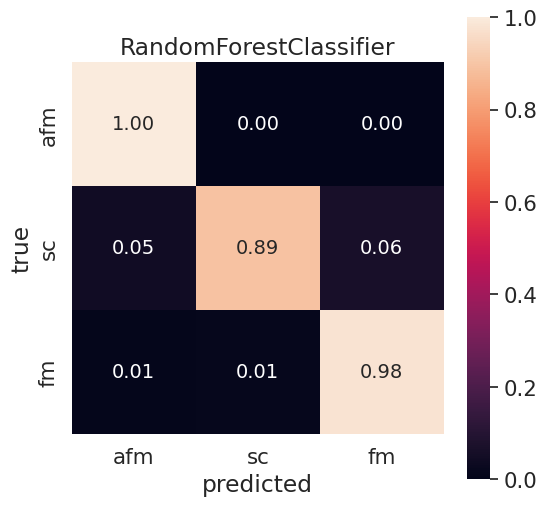

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9561041666666666),
   'prec': 0.9561041666666666,
   'rec': 0.9561041666666666,
   'f1': 0.9561041666666666},
  array([[1.        , 0.        , 0.        ],
         [0.04653125, 0.8908125 , 0.06265625],
         [0.00866875, 0.01383125, 0.9775    ]]))}

In [40]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
model_scores

### 04-1-1 train classifier on uncompressed vertex-samples

In [48]:
pc = PhaseClassification(None, pc_models, 11)

In [ ]:
pc.train(nce_train_dataset)

Load vertex samples:   0%|          | 0/59 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

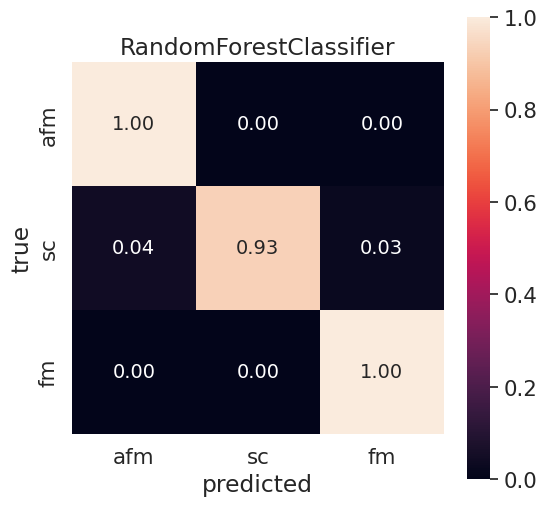

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9764937499999999),
   'prec': 0.97649375,
   'rec': 0.97649375,
   'f1': 0.97649375},
  array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [4.3806250e-02, 9.3067500e-01, 2.5518750e-02],
         [4.3750000e-05, 1.1500000e-03, 9.9880625e-01]]))}

In [51]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'1-1_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 04-1-2 train with Neural Network on uncompressed vertices

In [ ]:
in_dim = 24 * 6
net = phase_classification.NeuralNetClassifier(in_dim, [96, 48], 3, batch_size=config_kwargs['batch_size'], 
                                               num_workers=config_kwargs['num_dataloader_workers'], max_epochs=config_kwargs['epochs'])
pc = PhaseClassification(None, [net], 12)

In [ ]:
pc.train(train_dataset)

Load data:   0%|          | 0/51 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

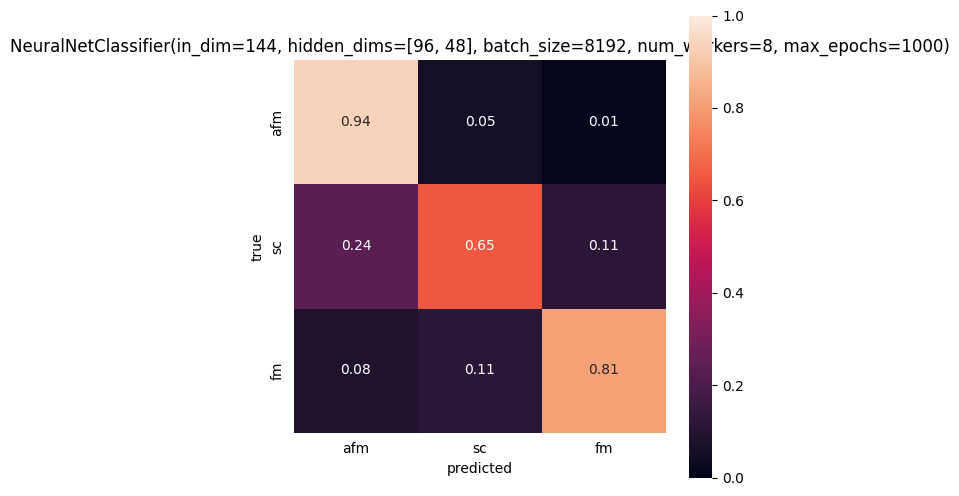

{'NeuralNetClassifier(in_dim=144, hidden_dims=[96, 48], batch_size=8192, num_workers=8, max_epochs=1000)': ({'acc': np.float64(0.7989808404558404),
   'prec': 0.8189705882352941,
   'rec': 0.8189705882352941,
   'f1': 0.8189705882352941},
  array([[0.936075  , 0.052325  , 0.0116    ],
         [0.23580769, 0.64992308, 0.11426923],
         [0.07905556, 0.11      , 0.81094444]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'1-2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 04-1-3 Use contrastive Autoencoder and classifer on latent space

In [ ]:
nce_train_dataset = verteval.make_dataset(vertices, 6000, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)

In [ ]:
test_dataset = verteval.make_dataset(vertices, test_samples_per_vertex, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)

In [ ]:
nce_train_dataset.return_filepaths = False
trainer = verteval.init_trainer(config_kwargs, nce_train_dataset, dataset_kwargs, model_wrapper='VertexWrapper24x6InfoNCE', 
                                model_name='ContrastiveAutoEncoder', batch_size=4096)
verteval.eval_train(trainer, info, info_fn, hidden_dims)
nce_train_dataset.return_filepaths = True

In [7]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-24/version_4'

In [8]:
# save_path = trainer.config.save_path
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-24/version_4/'
pc = PhaseClassification(save_path, pc_models, 13)

Model RandomForestClassifier(n_jobs=-1, random_state=14) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


In [9]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/88 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/30 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

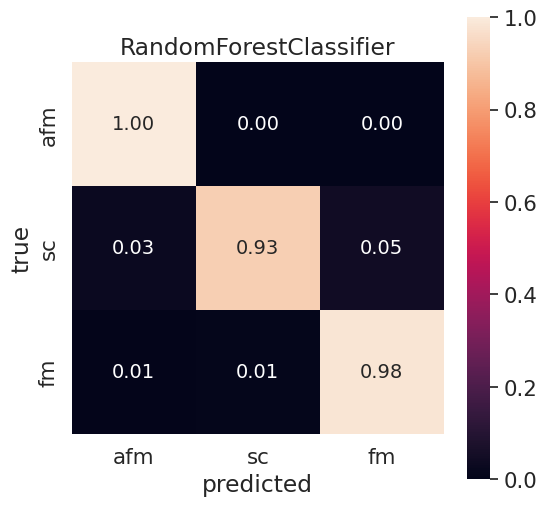

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.96941875),
   'prec': 0.96941875,
   'rec': 0.96941875,
   'f1': 0.96941875},
  array([[1.        , 0.        , 0.        ],
         [0.0296875 , 0.92530625, 0.04500625],
         [0.00588125, 0.01116875, 0.98295   ]]))}

In [12]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'1-3_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 04-2 Train/Test-split within each phase

* determine how well classification works for each phase

In [ ]:
train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs, subset=0.8, subset_type='phase')
test_dataset = verteval.make_test_from_train_dataset(vertices, path_train, dataset_kwargs, test_samples_per_vertex, nce_train_dataset)

In [ ]:
trainer = verteval.init_trainer(config_kwargs, train_dataset, dataset_kwargs)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_2'

### 04-2-0 default

In [21]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_2'
pc = PhaseClassification(save_path, pc_models, 20)

In [ ]:
pc.train(train_dataset)

Encode vertex samples:   0%|          | 0/51 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

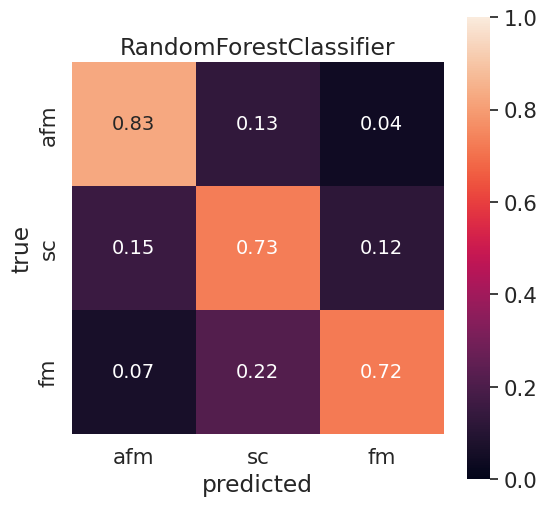

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.758268660968661),
   'prec': 0.7639607843137255,
   'rec': 0.7639607843137255,
   'f1': 0.7639607843137255},
  array([[0.82765   , 0.129575  , 0.042775  ],
         [0.15265385, 0.72796154, 0.11938462],
         [0.06530556, 0.2155    , 0.71919444]]))}

In [23]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 04-2-1 train classifier on uncompressed vertex-samples

In [24]:
pc = PhaseClassification(None, pc_models, 21)

In [ ]:
pc.train(train_dataset)

Load vertex samples:   0%|          | 0/51 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

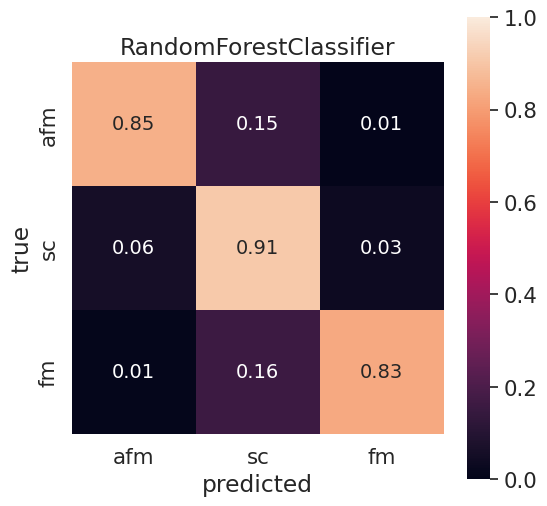

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.8625064814814815),
   'prec': 0.8573235294117647,
   'rec': 0.8573235294117647,
   'f1': 0.8573235294117647},
  array([[0.846575  , 0.1472    , 0.006225  ],
         [0.05630769, 0.909     , 0.03469231],
         [0.00822222, 0.15983333, 0.83194444]]))}

In [26]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'2-1_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 04-2-2 train with Neural Network

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_2'
in_dim = 32
net = phase_classification.NeuralNetClassifier(in_dim, [24, 12], 3, batch_size=config_kwargs['batch_size'], 
                                               num_workers=config_kwargs['num_dataloader_workers'], max_epochs=config_kwargs['epochs'])
pc = PhaseClassification(save_path, [net], 22)

In [ ]:
pc.train(train_dataset)

Load data:   0%|          | 0/21 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

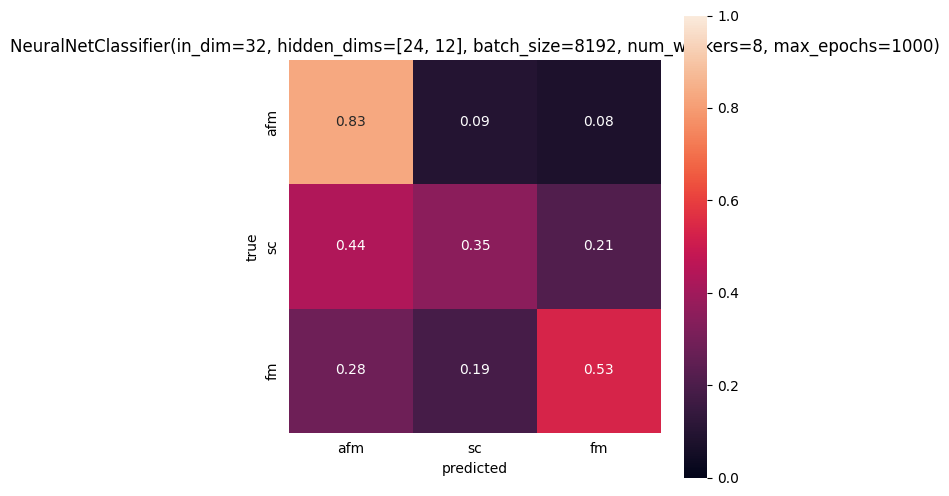

{'NeuralNetClassifier(in_dim=32, hidden_dims=[24, 12], batch_size=8192, num_workers=8, max_epochs=1000)': ({'acc': np.float64(0.5701208333333333),
   'prec': 0.6470952380952381,
   'rec': 0.6470952380952381,
   'f1': 0.6470952380952381},
  array([[0.82805   , 0.0939    , 0.07805   ],
         [0.43516667, 0.35      , 0.21483333],
         [0.2820625 , 0.185625  , 0.5323125 ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'2-2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 04-3 Use vertices from SC-phase as test set

* determine how well the phase can be extrapolated from latent space

In [ ]:
ae_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs, subset=0.8, subset_type=['afm', 'fm'])
train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs, subset=0.8)
nce_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex // 4, dataset_kwargs, subset=0.8, 
                                          dataset_class=AutoEncoder24x6InfoNCEDataset)
test_dataset = verteval.make_test_from_train_dataset(vertices, path_train, dataset_kwargs, test_samples_per_vertex, nce_train_dataset)

In [ ]:
trainer = verteval.init_trainer(config_kwargs, ae_train_dataset, dataset_kwargs)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_3'

In [52]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_3'

### 04-3-1 Exclude SC-phase from classifier-training

In [ ]:
ae_nce_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex // 4, dataset_kwargs, subset=0.8, 
                                             subset_type=['afm', 'fm'], dataset_class=AutoEncoder24x6InfoNCEDataset)

In [8]:
pc = PhaseClassification(save_path, pc_models, 3)

In [ ]:
pc.train(ae_nce_train_dataset)

Encode vertex samples:   0%|          | 0/15 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

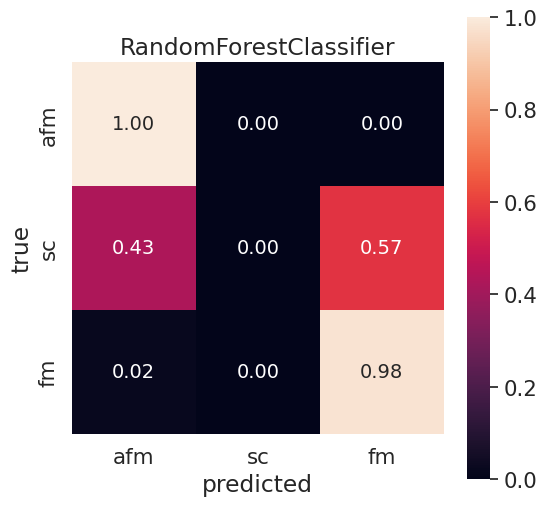

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.6588875),
   'prec': 0.6588875,
   'rec': 0.6588875,
   'f1': 0.6588875},
  array([[9.994500e-01, 0.000000e+00, 5.500000e-04],
         [4.286750e-01, 0.000000e+00, 5.713250e-01],
         [2.278750e-02, 0.000000e+00, 9.772125e-01]]))}

In [10]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-1_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 04-3-2 Include SC-phase in classifier training

#### 04-3-2-0 default

In [62]:
pc = PhaseClassification(save_path, pc_models, 40)

Model RandomForestClassifier(n_jobs=-1, random_state=14) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


In [63]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/36 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/3 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

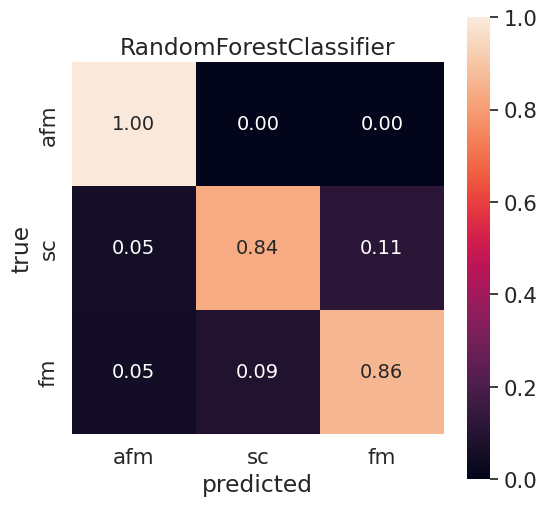

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.8978437499999999),
   'prec': 0.89784375,
   'rec': 0.89784375,
   'f1': 0.89784375},
  array([[0.9953125 , 0.00296875, 0.00171875],
         [0.05078125, 0.83528125, 0.1139375 ],
         [0.04853125, 0.08853125, 0.8629375 ]]))}

In [64]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 04-3-2-1 train with Neural Network

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_3'
in_dim = 32
net = phase_classification.NeuralNetClassifier(in_dim, [24, 12], 3, batch_size=config_kwargs['batch_size'], 
                                               num_workers=config_kwargs['num_dataloader_workers'], max_epochs=config_kwargs['epochs'])
pc = PhaseClassification(save_path, [net], 41)

In [ ]:
pc.train(train_dataset)

Load data:   0%|          | 0/10 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

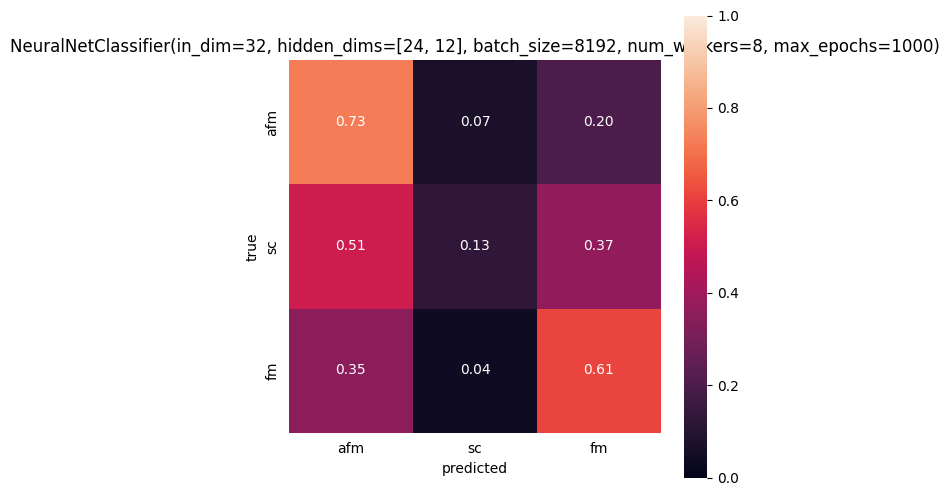

{'NeuralNetClassifier(in_dim=32, hidden_dims=[24, 12], batch_size=8192, num_workers=8, max_epochs=1000)': ({'acc': np.float64(0.49009722222222224),
   'prec': 0.5024,
   'rec': 0.5024,
   'f1': 0.5024},
  array([[0.7285    , 0.06866667, 0.20283333],
         [0.5055    , 0.12866667, 0.36583333],
         [0.350125  , 0.03675   , 0.613125  ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-1_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 04-3-2-2 Use contrastive Autoencoder and classifer on latent space (exclude SC)

In [ ]:
ae_nce_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex // 4, dataset_kwargs, subset=0.8, 
                                             subset_type=['afm', 'fm'], dataset_class=AutoEncoder24x6InfoNCEDataset, return_filepaths=False)

In [ ]:
trainer = verteval.init_trainer(config_kwargs, ae_nce_train_dataset, dataset_kwargs, model_wrapper='VertexWrapper24x6InfoNCE', 
                                model_name='ContrastiveAutoEncoder', batch_size=4096)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [19]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-15/version_2'

In [65]:
# save_path = trainer.config.save_path
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-15/version_2'
pc = PhaseClassification(save_path, pc_models, 42)

In [ ]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/6 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

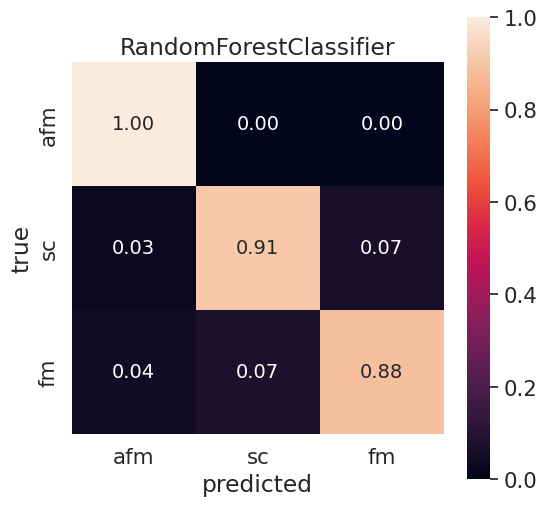

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9308958333333334),
   'prec': 0.9308958333333334,
   'rec': 0.9308958333333334,
   'f1': 0.9308958333333334},
  array([[9.9893750e-01, 4.3750000e-04, 6.2500000e-04],
         [2.5218750e-02, 9.0953125e-01, 6.5250000e-02],
         [4.4312500e-02, 7.1468750e-02, 8.8421875e-01]]))}

In [71]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 04-3-2-3 Use contrastive Autoencoder and classifer on latent space (exclude AFM)

In [ ]:
ae_nce_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex // 4, dataset_kwargs, subset=0.8, 
                                             subset_type=['sc', 'fm'], dataset_class=AutoEncoder24x6InfoNCEDataset, return_filepaths=False)

In [ ]:
trainer = verteval.init_trainer(config_kwargs, ae_nce_train_dataset, dataset_kwargs, model_wrapper='VertexWrapper24x6InfoNCE', 
                                model_name='ContrastiveAutoEncoder', batch_size=4096)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [7]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-21/version_0'

In [72]:
# save_path = trainer.config.save_path
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-21/version_0'
pc = PhaseClassification(save_path, pc_models, 43)

In [73]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/71 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/6 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

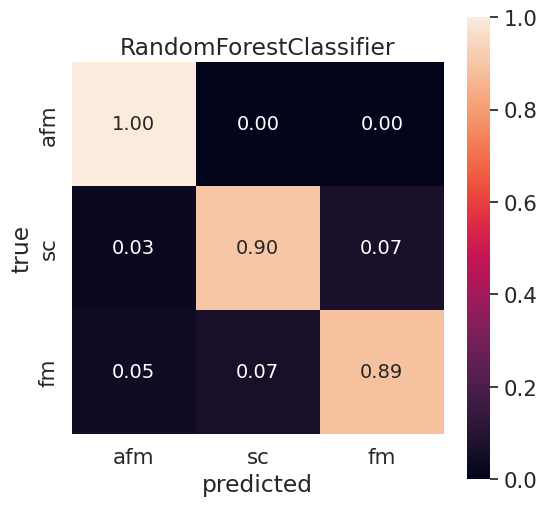

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9296979166666667),
   'prec': 0.9296979166666667,
   'rec': 0.9296979166666667,
   'f1': 0.9296979166666667},
  array([[9.9853125e-01, 6.8750000e-04, 7.8125000e-04],
         [2.7968750e-02, 9.0212500e-01, 6.9906250e-02],
         [4.6125000e-02, 6.5437500e-02, 8.8843750e-01]]))}

In [74]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-3_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

Encode vertex samples:   0%|          | 0/30 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

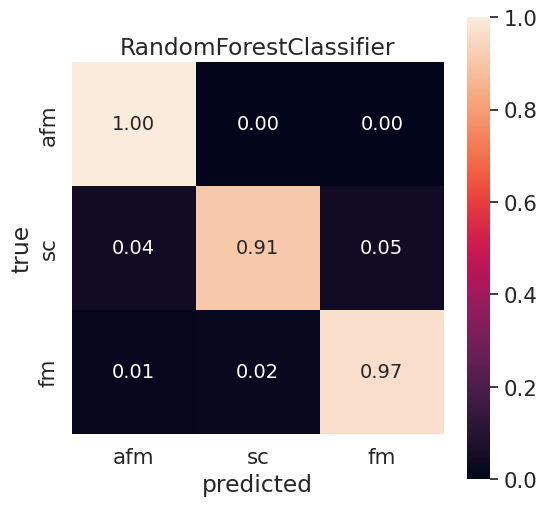

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9582104166666666),
   'prec': 0.9582104166666666,
   'rec': 0.9582104166666666,
   'f1': 0.9582104166666666},
  array([[9.9970625e-01, 1.3750000e-04, 1.5625000e-04],
         [4.4812500e-02, 9.0877500e-01, 4.6412500e-02],
         [1.3275000e-02, 2.0575000e-02, 9.6615000e-01]]))}

In [11]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-3_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 04-3-2-4 Use contrastive Autoencoder and classifer on latent space (exclude FM)

In [ ]:
ae_nce_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex // 4, dataset_kwargs, subset=0.8, 
                                             subset_type=['afm', 'sc'], dataset_class=AutoEncoder24x6InfoNCEDataset, return_filepaths=False)

In [ ]:
trainer = verteval.init_trainer(config_kwargs, ae_nce_train_dataset, dataset_kwargs, model_wrapper='VertexWrapper24x6InfoNCE', 
                                model_name='ContrastiveAutoEncoder', batch_size=4096, epochs=5000)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [13]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-24/version_5'

In [20]:
# save_path = trainer.config.save_path
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-24/version_5'
pc = PhaseClassification(save_path, pc_models, 44)

In [ ]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/6 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

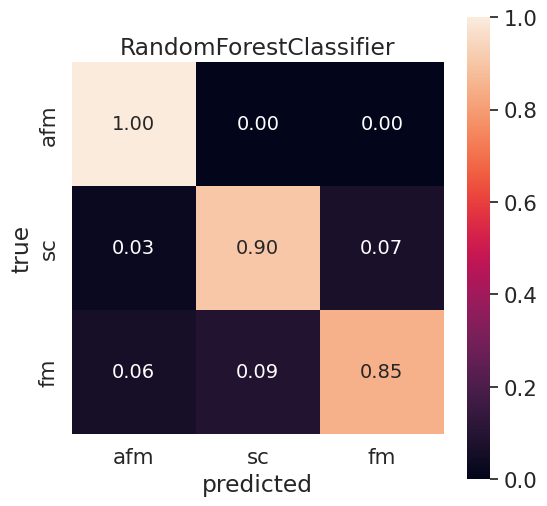

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9169895833333334),
   'prec': 0.9169895833333334,
   'rec': 0.9169895833333334,
   'f1': 0.9169895833333334},
  array([[0.99721875, 0.00103125, 0.00175   ],
         [0.02784375, 0.9038125 , 0.06834375],
         [0.05934375, 0.09071875, 0.8499375 ]]))}

In [22]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-4_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

Encode vertex samples:   0%|          | 0/30 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

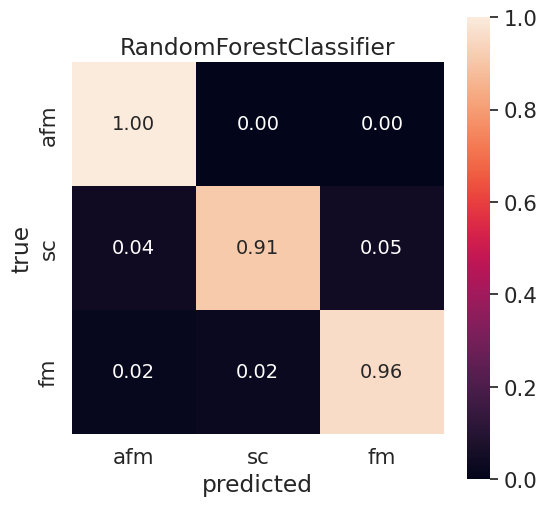

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9568958333333334),
   'prec': 0.9568958333333333,
   'rec': 0.9568958333333333,
   'f1': 0.9568958333333333},
  array([[9.995125e-01, 1.625000e-04, 3.250000e-04],
         [3.966875e-02, 9.135375e-01, 4.679375e-02],
         [1.789375e-02, 2.446875e-02, 9.576375e-01]]))}

In [17]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-4_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## convergence

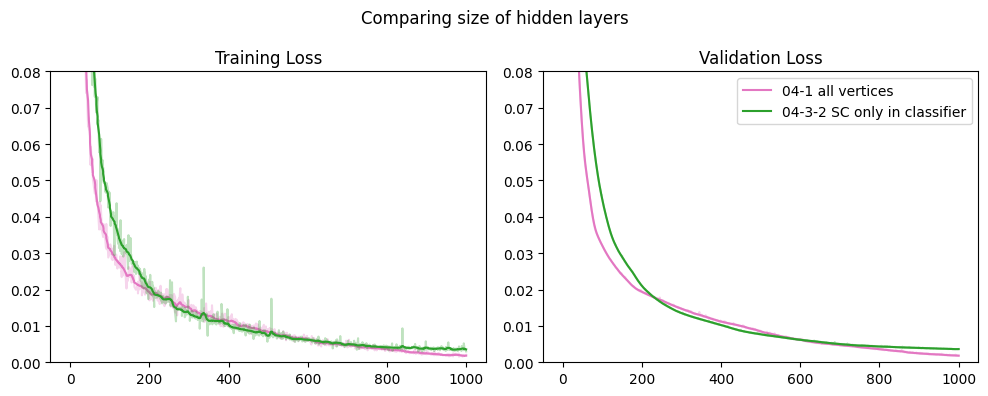

In [3]:
train_data_files = ['../../saves/tensorboard/BS8192_2025-03-22_version_1_train.csv', 
                    '../../saves/tensorboard/BS8192_2025-03-22_version_3_train.csv']
val_data_files = ['../../saves/tensorboard/BS8192_2025-03-22_version_1_val.csv', 
                    '../../saves/tensorboard/BS8192_2025-03-22_version_3_val.csv']
labels = ['04-1 all vertices', '04-3-2 SC only in classifier']
title = 'Comparing size of hidden layers'

vis.plot_training_progress(train_data_files, val_data_files, labels, title, y_max=0.08)

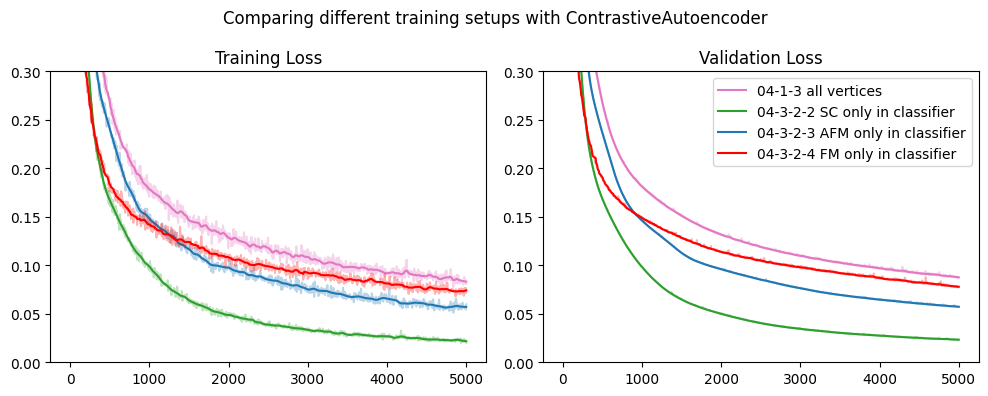

In [9]:
train_data_files = ['../../saves/tensorboard/BS4096_2025-05-24_version_4_train.csv',
                    '../../saves/tensorboard/BS4096_2025-05-15_version_2_train.csv',
                    '../../saves/tensorboard/BS4096_2025-05-21_version_0_train.csv',
                    '../../saves/tensorboard/BS4096_2025-05-24_version_5_train.csv',]
val_data_files = ['../../saves/tensorboard/BS4096_2025-05-24_version_4_val.csv',
                  '../../saves/tensorboard/BS4096_2025-05-15_version_2_val.csv',
                  '../../saves/tensorboard/BS4096_2025-05-21_version_0_val.csv',
                  '../../saves/tensorboard/BS4096_2025-05-24_version_5_val.csv',]
labels = ['04-1-3 all vertices', '04-3-2-2 SC only in classifier', '04-3-2-3 AFM only in classifier', '04-3-2-4 FM only in classifier']
title = 'Comparing different training setups with ContrastiveAutoencoder'

vis.plot_training_progress(train_data_files, val_data_files, labels, title, y_max=0.3, y_min=0, n_epochs=5000)

## reconstruction error

In [ ]:
# 04-1-0
train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs)
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_1'
preds = verteval.predict_all(train_dataset, file_paths, vertices, path_train, save_path, config_kwargs, dataset_kwargs, 
                             encode_only=False, all_vertices=True)

In [ ]:
verteval.mean_rmse(file_paths, vertices, path_train, save_path)

  0%|          | 0/51 [00:00<?, ?it/s]

mean: 0.03975294625119755, min: 0.011375393126232685, max: 0.06751797477808208


In [ ]:
# 04-1-3
train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs)
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-24/version_4/'
preds = verteval.predict_all(train_dataset, file_paths, vertices, path_train, save_path, config_kwargs, dataset_kwargs, 
                             encode_only=False, all_vertices=True)

  0%|          | 0/51 [00:00<?, ?it/s]

/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../phys_ml/visualization/vertex_visualization.py:115: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(nrows, ncols, figsize=figsize, layout='compressed', subplot_kw={'aspect': 'equal'})


mean: 0.14056061620085245, min: 0.06046016637405216, max: 0.21908840287416495


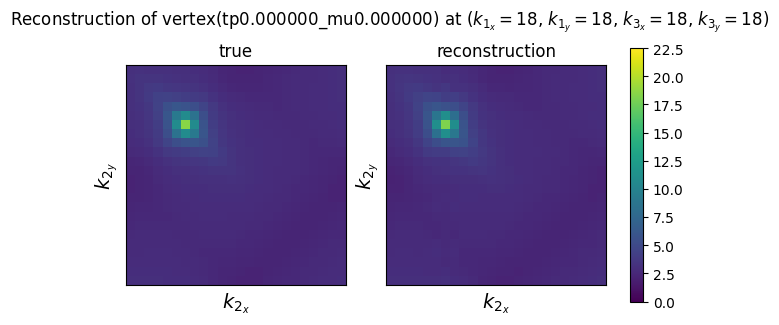

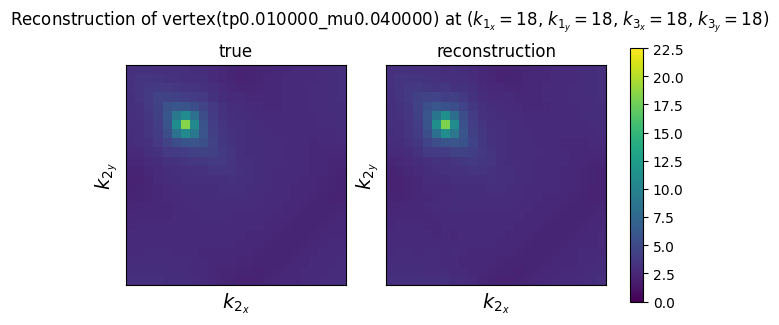

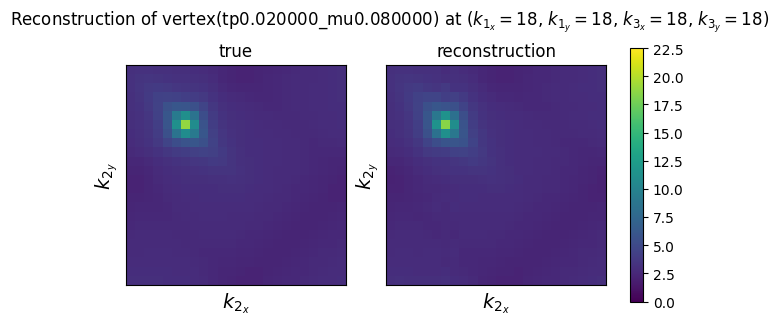

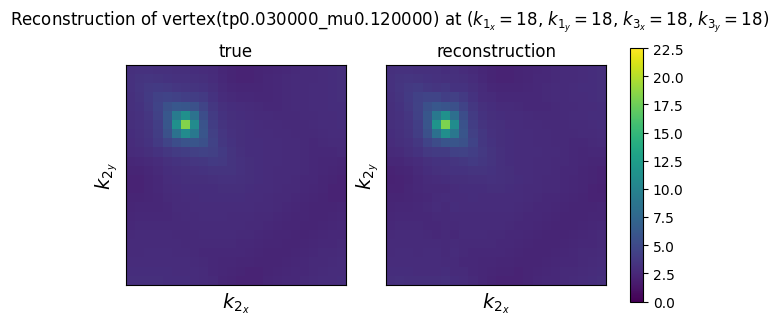

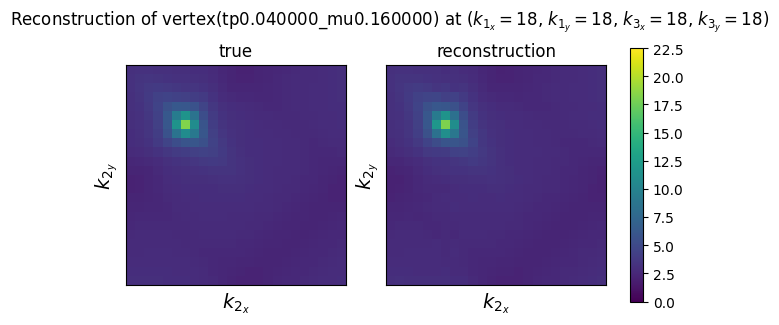

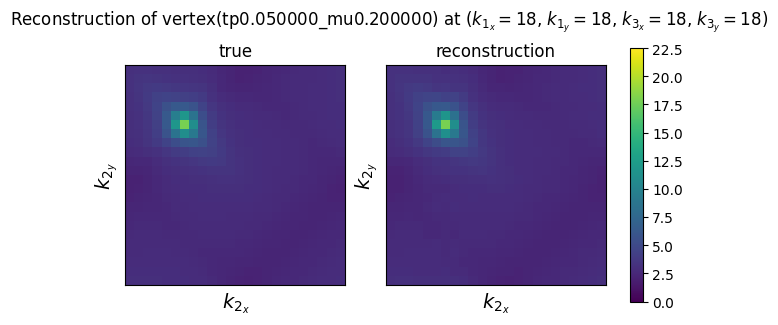

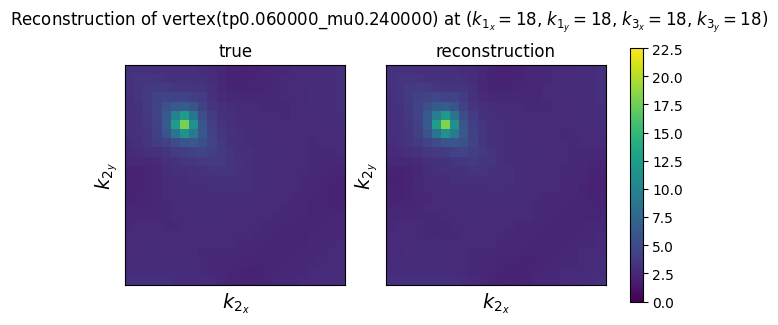

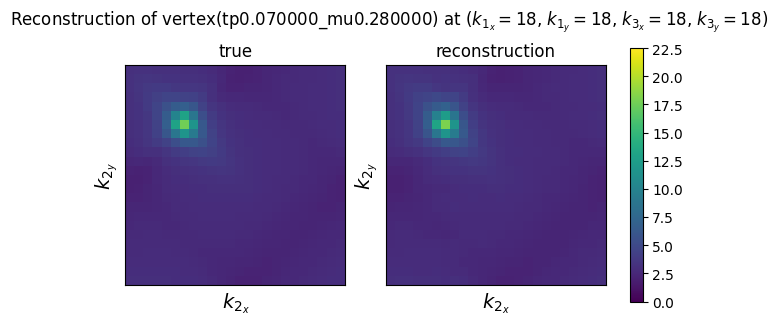

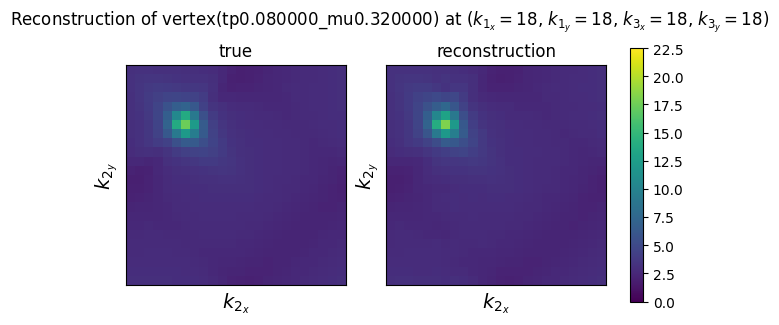

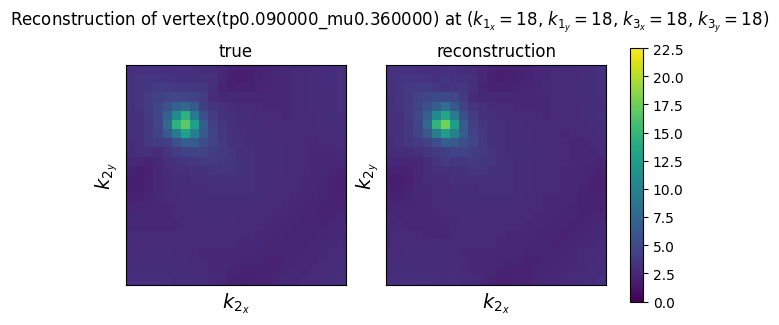

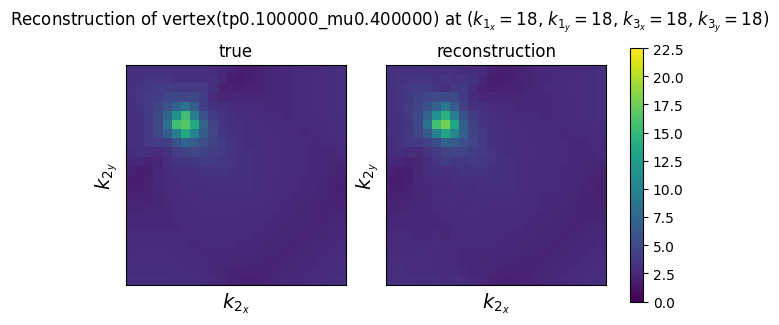

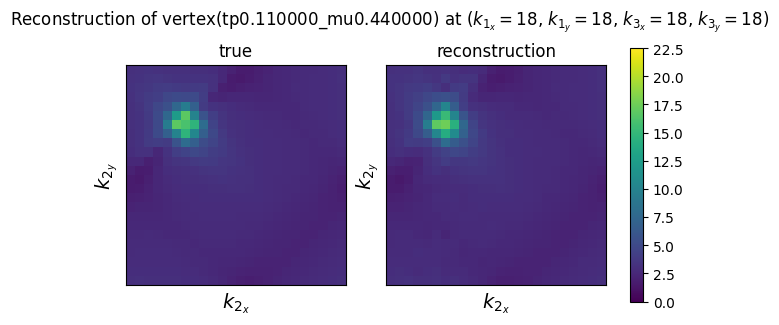

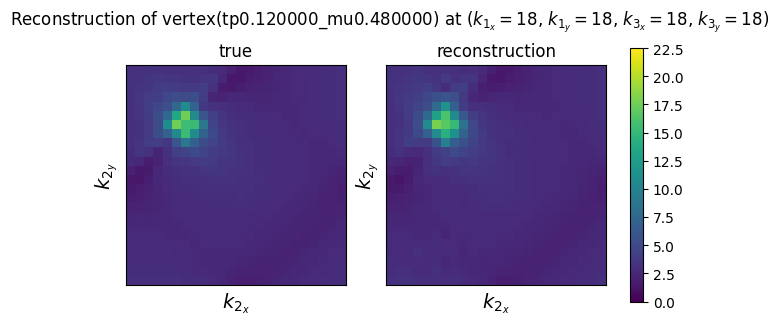

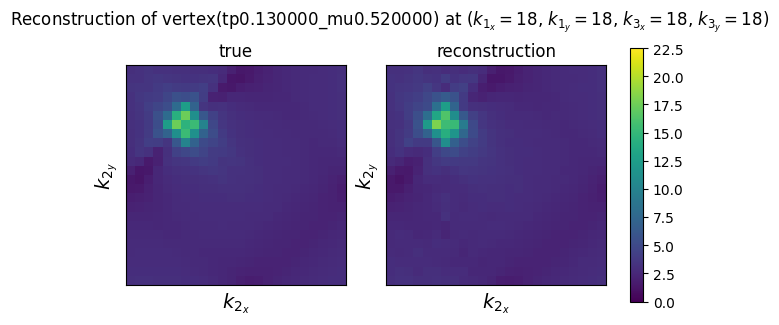

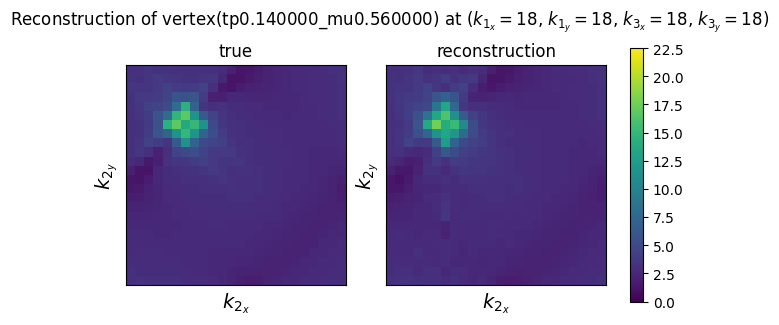

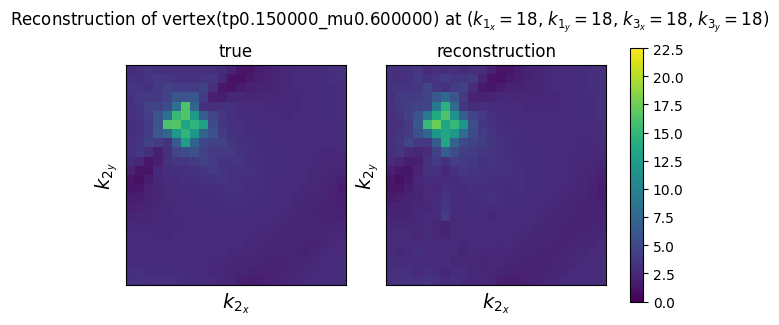

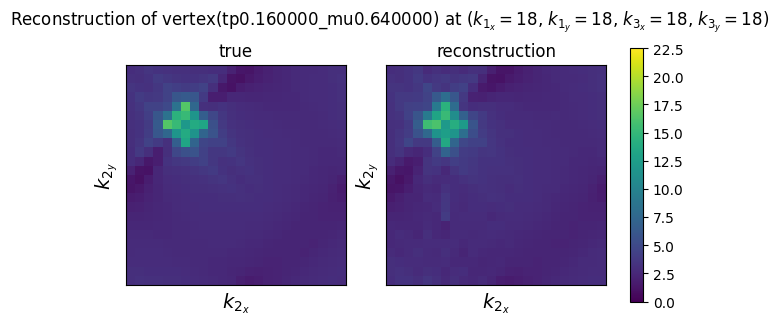

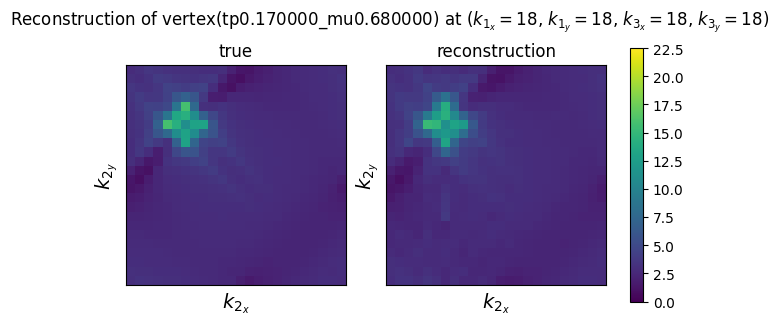

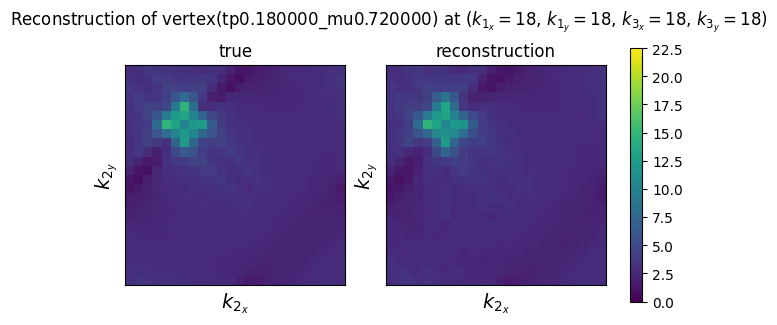

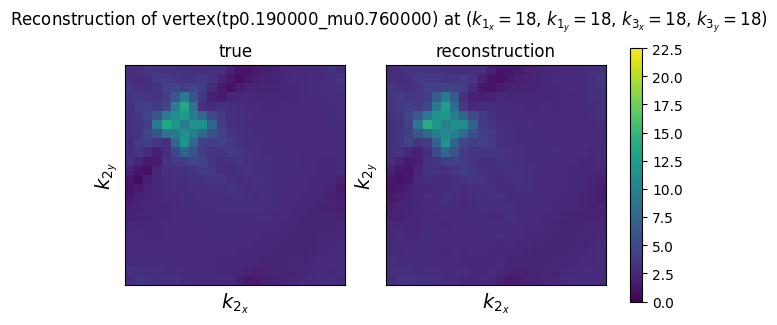

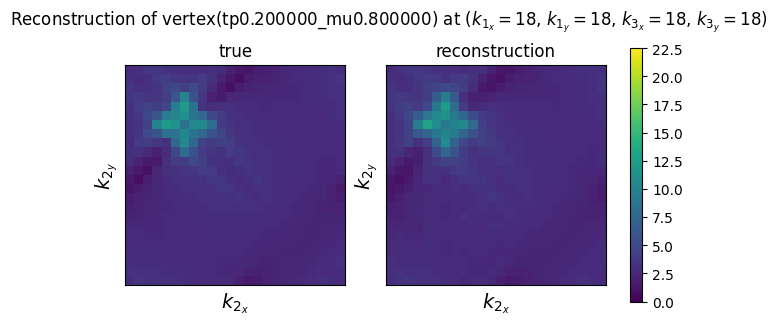

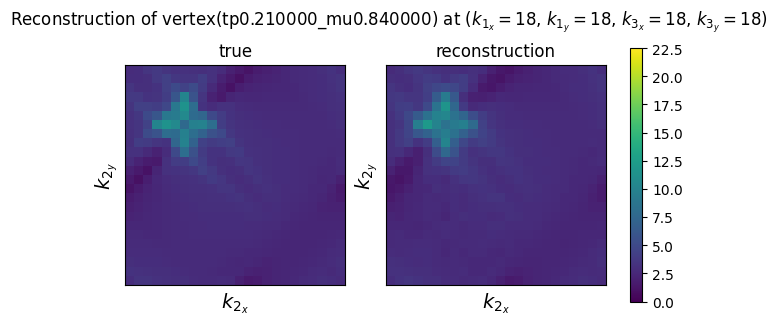

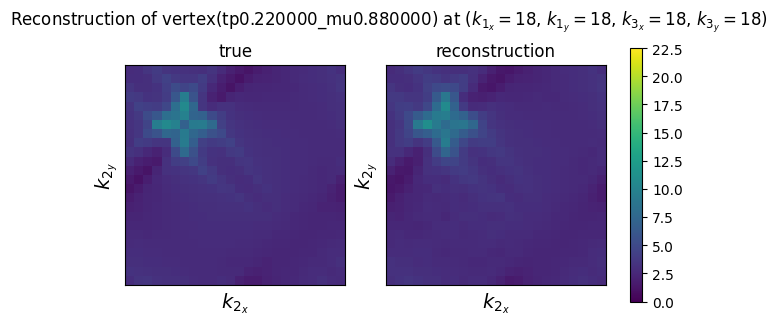

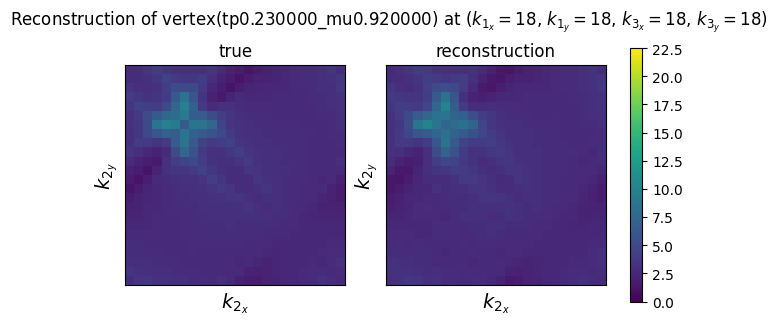

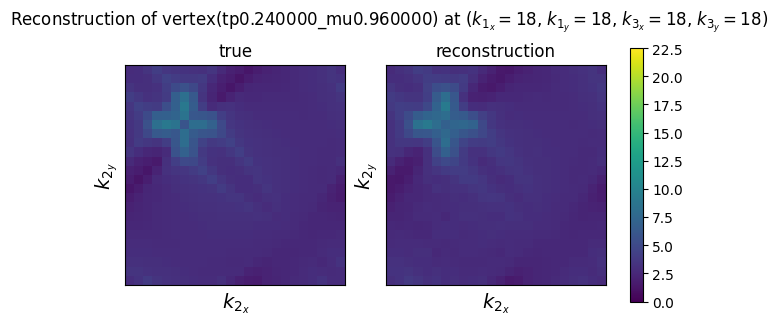

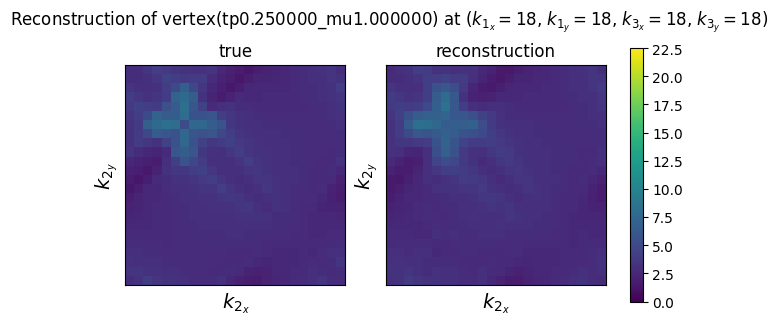

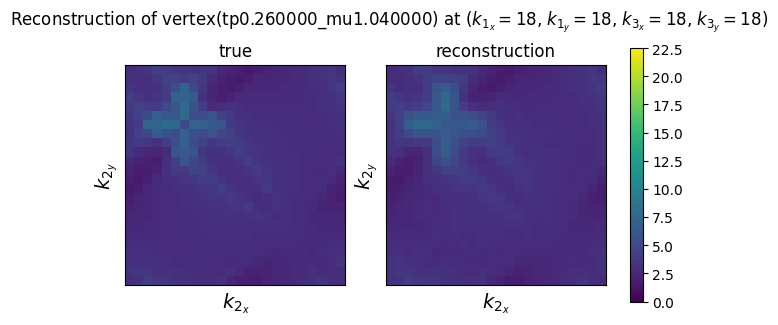

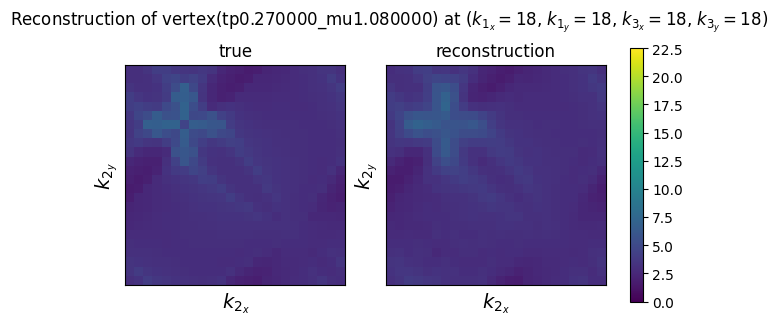

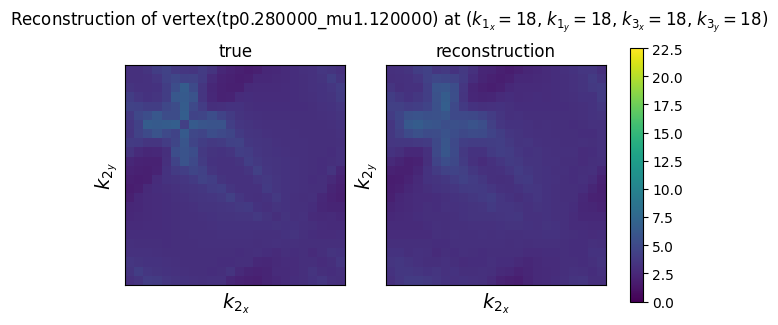

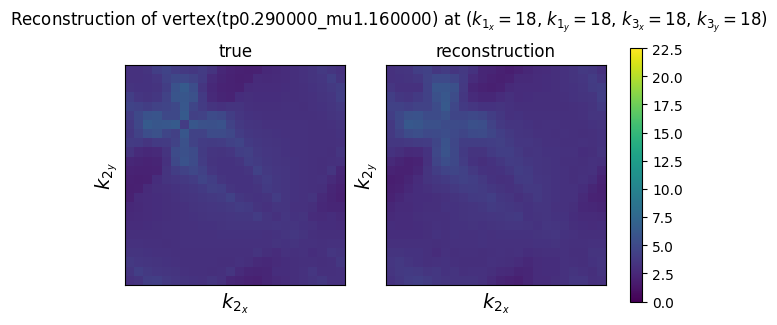

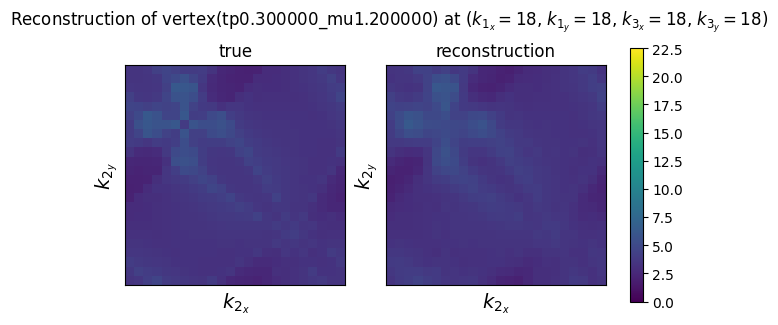

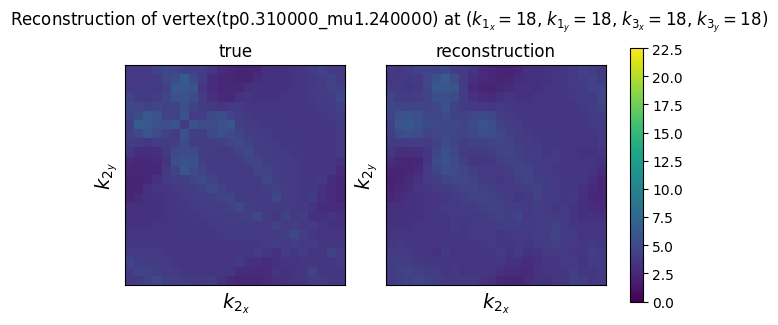

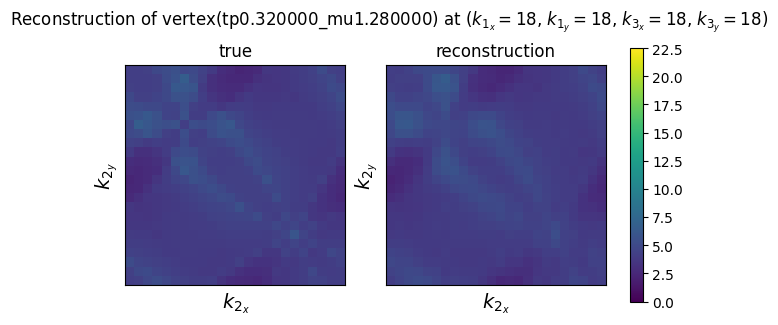

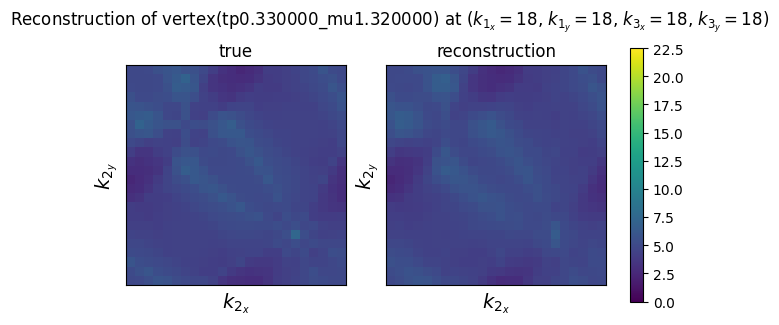

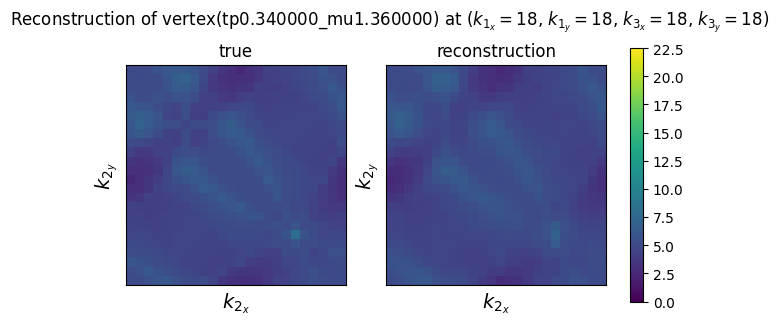

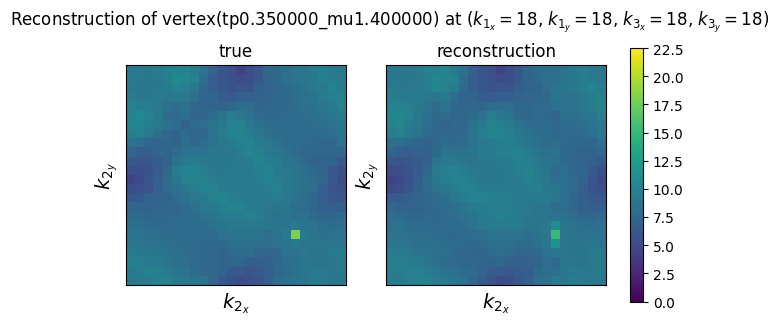

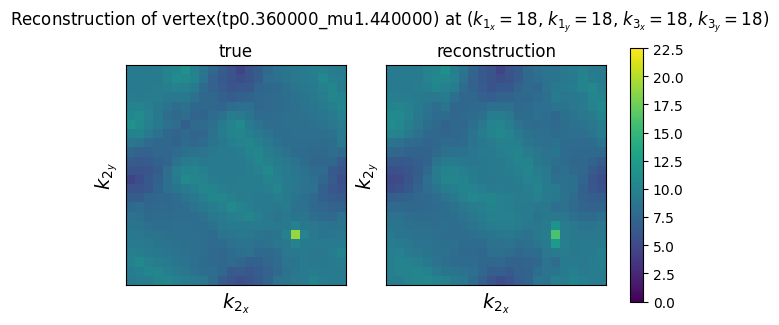

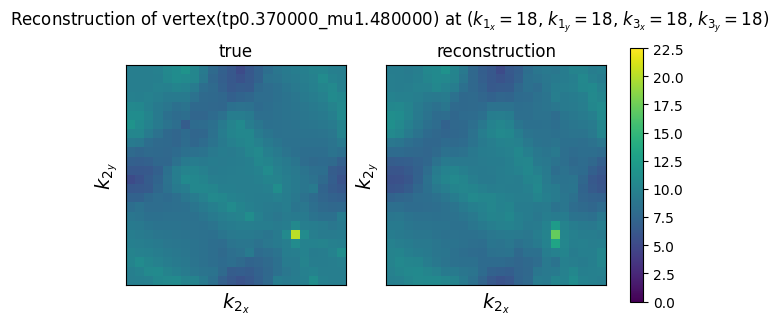

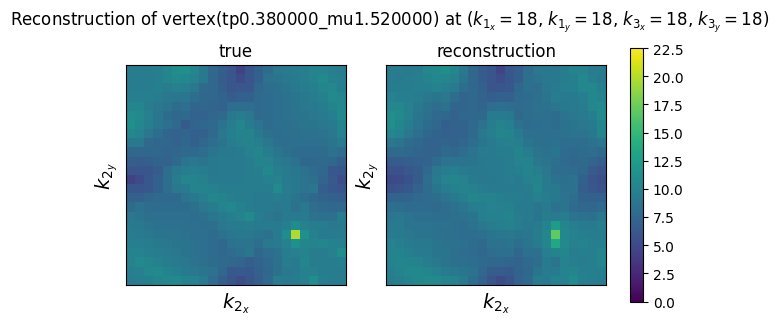

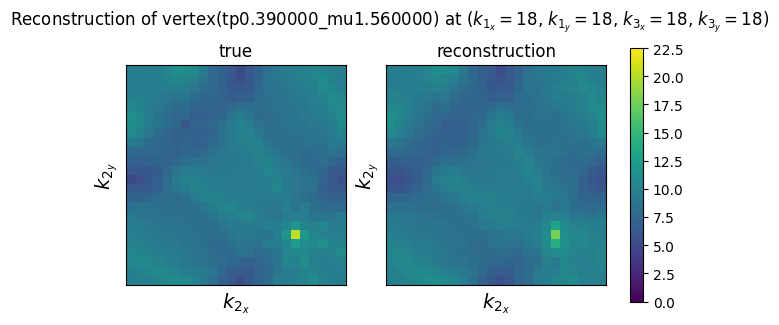

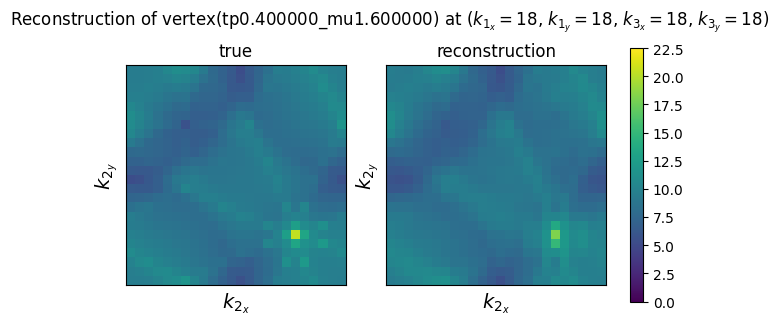

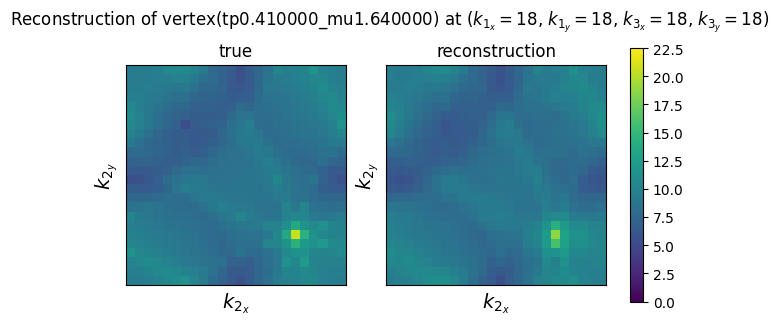

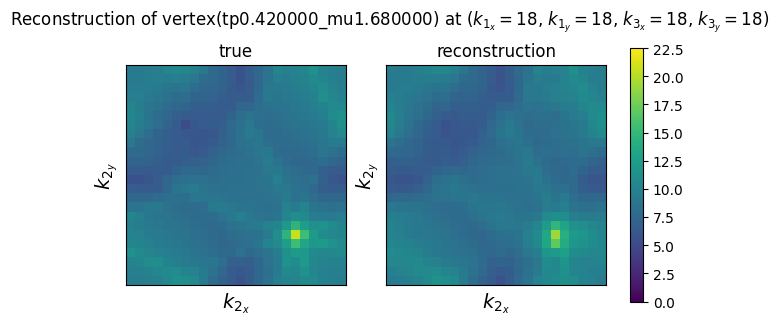

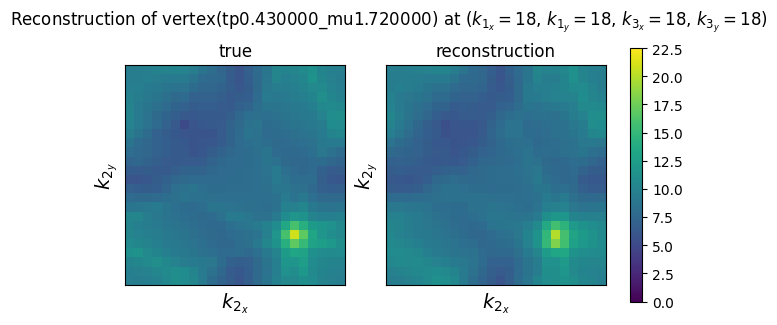

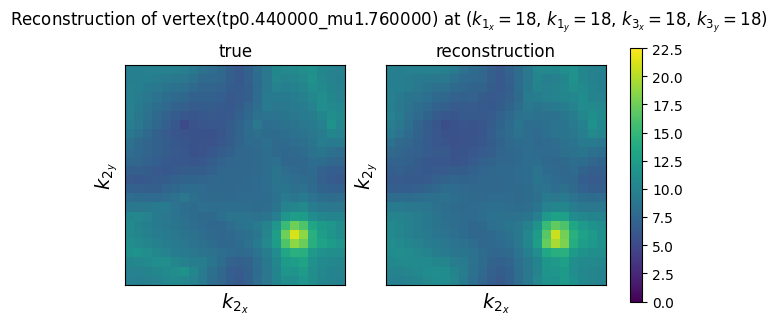

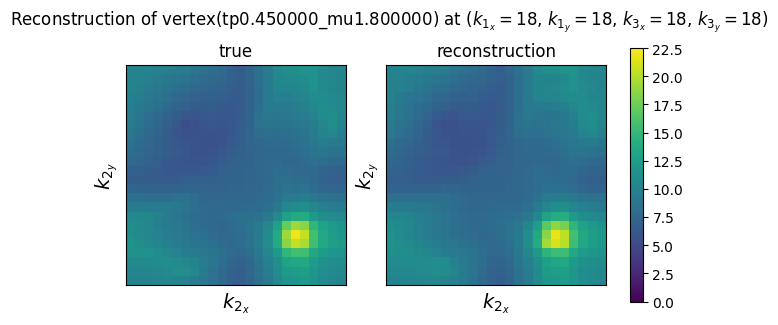

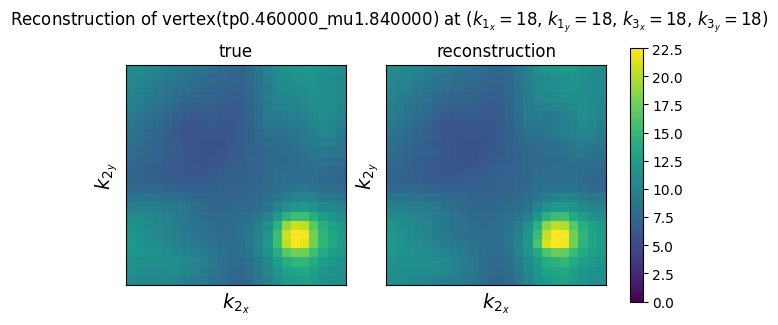

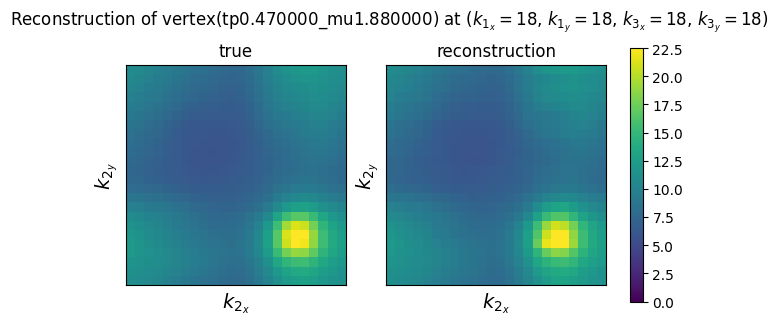

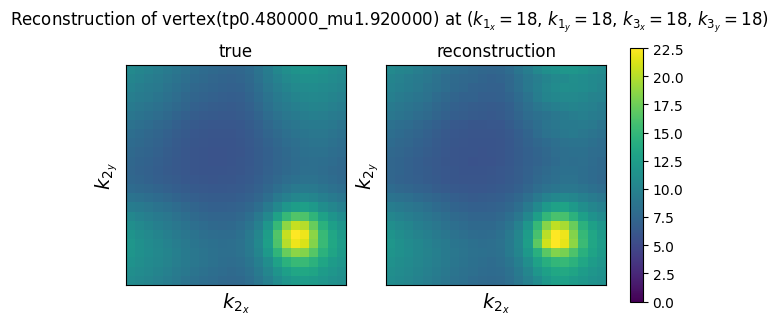

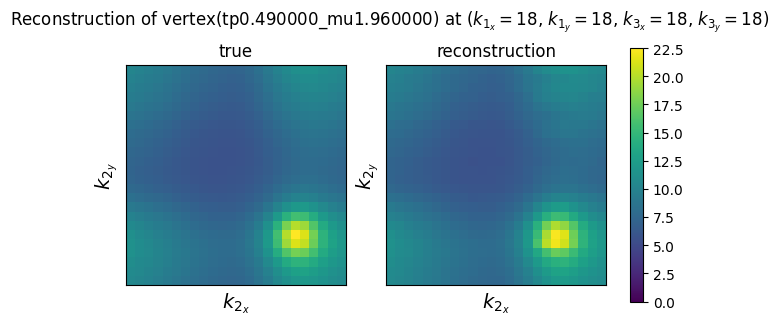

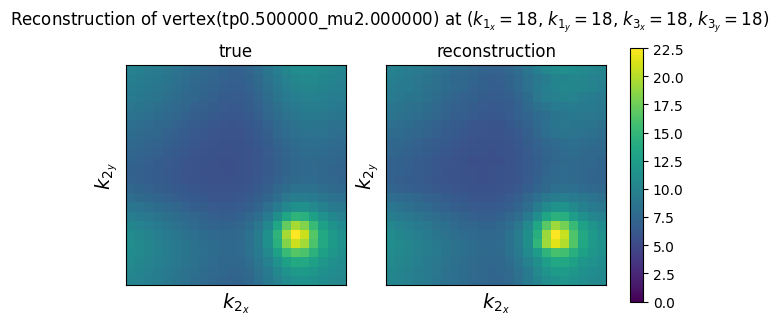

In [ ]:
verteval.mean_rmse(file_paths, vertices, path_train, save_path, plot=True)

In [ ]:
# 04-3-2-0
ae_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs, subset=0.8, subset_type=['afm', 'fm'])
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_3'
preds = verteval.predict_all(ae_train_dataset, file_paths, vertices, path_train, save_path, config_kwargs, dataset_kwargs, encode_only=False)

In [ ]:
verteval.mean_rmse(file_paths, vertices, path_train, save_path, ae_train_dataset)

  0%|          | 0/21 [00:00<?, ?it/s]

mean: 0.09985708897638512, min: 0.020177444282703707, max: 0.1560841647372492


In [ ]:
# 04-3-2-2
ae_nce_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex // 4, dataset_kwargs, subset=0.8, subset_type=['afm', 'fm'], 
                                             dataset_class=AutoEncoder24x6InfoNCEDataset, return_filepaths=False)
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-15/version_2'
preds = verteval.predict_all(ae_nce_train_dataset, file_paths, vertices, path_train, save_path, config_kwargs, dataset_kwargs, encode_only=False)

In [ ]:
verteval.mean_rmse(file_paths, vertices, path_train, save_path, ae_nce_train_dataset)

  0%|          | 0/21 [00:00<?, ?it/s]

mean: 0.17174875685861382, min: 0.0592030703406091, max: 0.2311304161423688


In [ ]:
# 04-3-2-3
ae_nce_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex // 4, dataset_kwargs, subset=0.8, subset_type=['sc', 'fm'], 
                                             dataset_class=AutoEncoder24x6InfoNCEDataset, return_filepaths=False)
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-21/version_0'
preds = verteval.predict_all(ae_nce_train_dataset, file_paths, vertices, path_train, save_path, config_kwargs, dataset_kwargs, 
                             encode_only=False)

In [ ]:
verteval.mean_rmse(file_paths, vertices, path_train, save_path, ae_nce_train_dataset)

  0%|          | 0/27 [00:00<?, ?it/s]

mean: 0.1803050700579682, min: 0.10811403748664321, max: 0.3085794649678681


In [ ]:
# 04-3-2-4
ae_nce_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex // 4, dataset_kwargs, subset=0.8, subset_type=['afm', 'sc'], 
                                             dataset_class=AutoEncoder24x6InfoNCEDataset, return_filepaths=False)
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-21/version_1'
preds = verteval.predict_all(ae_nce_train_dataset, file_paths, vertices, path_train, save_path, config_kwargs, dataset_kwargs, 
                             encode_only=False)

In [ ]:
verteval.mean_rmse(file_paths, vertices, path_train, save_path, ae_nce_train_dataset)

  0%|          | 0/25 [00:00<?, ?it/s]

mean: 0.16902461837984312, min: 0.06914491868222898, max: 0.2747144184305769


## correlation analysis

In [ ]:
vertex_dir = "/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-09/version_0/latentspaces"
cor_mat = verteval.vertex_correlation(vertex_dir=vertex_dir, pre_load_vertices=True, vertex_file_ending='npy')

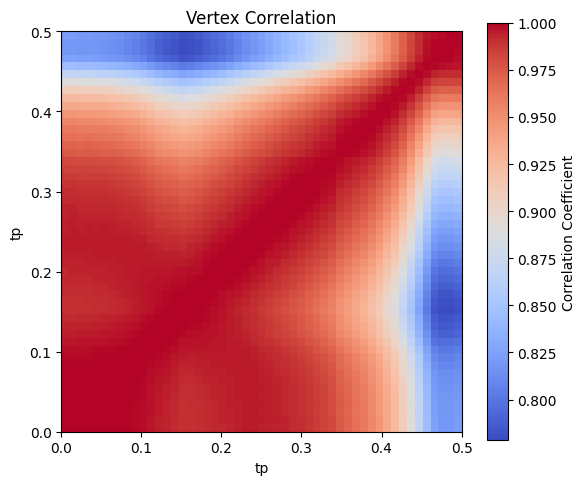

In [4]:
vertvis.plot_correlation(cor_mat, "Vertex Correlation")

# 05 Phase regression

In [20]:
mode = 'r'
pc_models = [
    # svm.SVR(), 
    # phase_classification.PolynomialRegression.new(degree=2),
    # phase_classification.PolynomialRegression.new(degree=4),
    ensemble.RandomForestRegressor(n_jobs=-1, random_state=seed + 1),
]

## 05-1 All vertices

In [ ]:
train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs)

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_1'
pc = PhaseClassification(save_path, pc_models, 1, mode)

In [ ]:
pc.train(train_dataset)

Model PolynomialRegression(degree=4) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


Load data:   0%|          | 0/51 [00:00<?, ?it/s]

Predict:   0%|          | 0/3 [00:00<?, ?it/s]

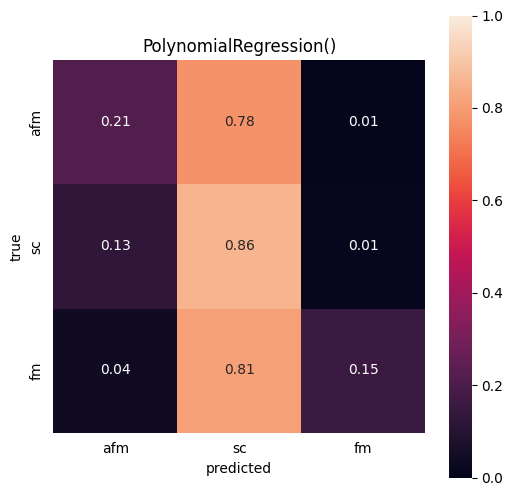

Skipping model PolynomialRegression(degree=4), which could not be fitted.


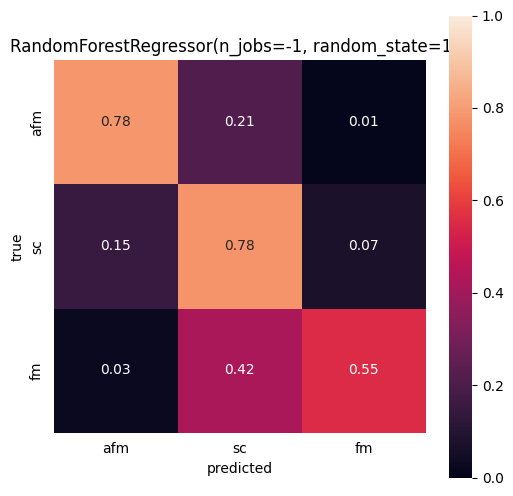

{'PolynomialRegression()': ({'rmse': 0.1356355612791372,
   'acc': np.float64(0.40874280626780624),
   'prec': 0.357,
   'rec': 0.357,
   'f1': 0.357},
  array([[0.214175  , 0.776425  , 0.0094    ],
         [0.12661538, 0.85869231, 0.01469231],
         [0.04130556, 0.80533333, 0.15336111]])),
 'PolynomialRegression(degree=4)': (None, None),
 'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.07988664543969688,
   'acc': np.float64(0.7046866096866097),
   'prec': 0.7005098039215686,
   'rec': 0.7005098039215686,
   'f1': 0.7005098039215686},
  array([[0.783     , 0.20825   , 0.00875   ],
         [0.14946154, 0.77861538, 0.07192308],
         [0.02686111, 0.42069444, 0.55244444]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'1_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 05-2 Train/Test-split within each phase

In [ ]:
train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs, subset=0.8, subset_type='phase')

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_2'
pc = PhaseClassification(save_path, pc_models, 2, mode)

In [ ]:
path_train = '../../../frgs_6d'
train_files = pc.vertex_trainer.dataset.file_paths
test_files = [f for f in glob.glob(f"{path_train}/*.h5") if f not in train_files]
pc.train(train_dataset)

Load data:   0%|          | 0/11 [00:00<?, ?it/s]

Predict:   0%|          | 0/2 [00:00<?, ?it/s]

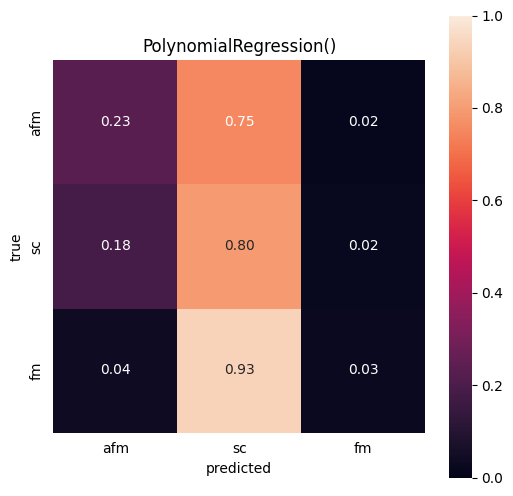

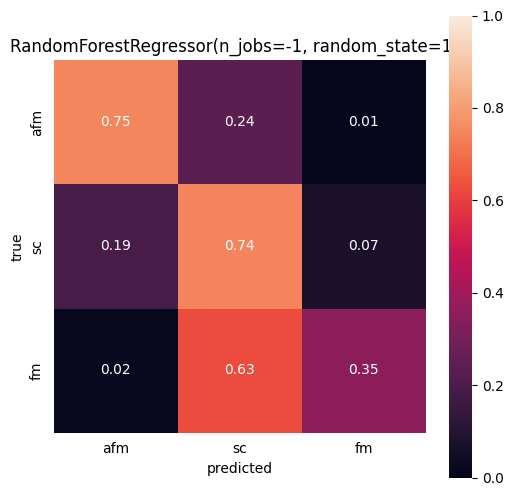

{'PolynomialRegression()': ({'rmse': 0.12149857187464187,
   'acc': np.float64(0.35297222222222224),
   'prec': 0.31272727272727274,
   'rec': 0.31272727272727274,
   'f1': 0.31272727272727274},
  array([[0.233625  , 0.750875  , 0.0155    ],
         [0.1835    , 0.79566667, 0.02083333],
         [0.036125  , 0.93425   , 0.029625  ]])),
 'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.07506055254683623,
   'acc': np.float64(0.6148611111111112),
   'prec': 0.6030454545454546,
   'rec': 0.6030454545454546,
   'f1': 0.6030454545454546},
  array([[0.749875  , 0.238     , 0.012125  ],
         [0.1875    , 0.74483333, 0.06766667],
         [0.023125  , 0.627     , 0.349875  ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'2_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 05-3 Use vertices from SC-phase as test set

* determine how well the phase can be extrapolated from latent space

In [ ]:
ae_train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs, subset=0.8, subset_type=['afm', 'fm'])
train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs, subset=0.8)

### 05-3-1 Exclude SC-phase from classifier-training

In [4]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_3'
pc = PhaseClassification(save_path, pc_models, 3, mode)

Model PolynomialRegression() is not fitted and could not be loaded. Call train() before using the PhaseClassifier.
Model RandomForestRegressor(n_jobs=-1, random_state=13) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


In [ ]:
pc.train(ae_train_dataset)

Load data:   0%|          | 0/21 [00:00<?, ?it/s]

Predict:   0%|          | 0/2 [00:00<?, ?it/s]

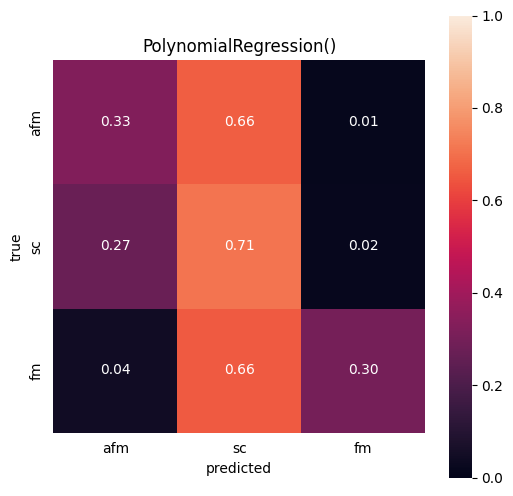

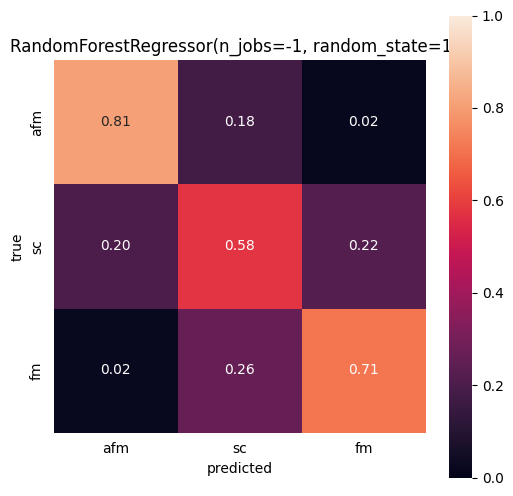

{'PolynomialRegression()': ({'rmse': 0.10650268940432761,
   'acc': np.float64(0.44498397435897435),
   'prec': 0.5581666666666667,
   'rec': 0.5581666666666667,
   'f1': 0.5581666666666667},
  array([[0.32525   , 0.6605    , 0.01425   ],
         [0.27176923, 0.70907692, 0.01915385],
         [0.043875  , 0.6555    , 0.300625  ]])),
 'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.07531124258543279,
   'acc': np.float64(0.699451923076923),
   'prec': 0.6466428571428572,
   'rec': 0.6466428571428572,
   'f1': 0.6466428571428572},
  array([[0.807875  , 0.176375  , 0.01575   ],
         [0.20134615, 0.57623077, 0.22242308],
         [0.021     , 0.26475   , 0.71425   ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-1_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 05-3-2 Include SC-phase in classifier training

#### 05-3-2-0 default

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_3'
pc = PhaseClassification(save_path, pc_models, 40, mode)

In [ ]:
pc.train(train_dataset)

Load data:   0%|          | 0/10 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

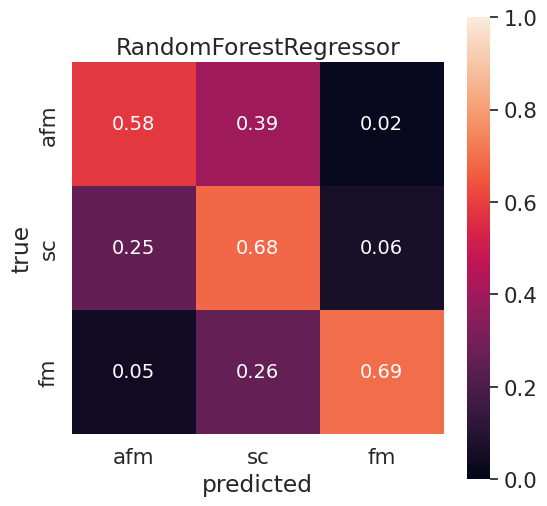

{'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.09164959511912749,
   'acc': np.float64(0.6537083333333333),
   'prec': 0.65775,
   'rec': 0.65775,
   'f1': 0.65775},
  array([[0.58416667, 0.393     , 0.02283333],
         [0.2545    , 0.68283333, 0.06266667],
         [0.04525   , 0.260625  , 0.694125  ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 05-3-2-1 Use contrastive Autoencoder and classifer on latent space (exclude SC)

In [21]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-15/version_2'
pc = PhaseClassification(save_path, pc_models, 41, mode)

Model RandomForestRegressor(n_jobs=-1, random_state=13) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


In [ ]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/30 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

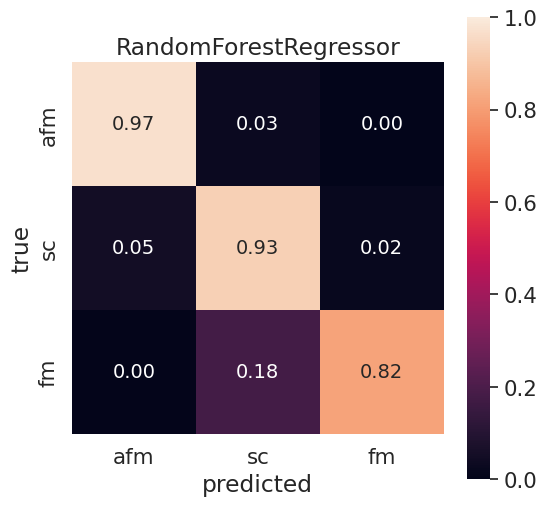

{'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.03370873794853991,
   'acc': np.float64(0.9055145833333332),
   'prec': 0.9055145833333333,
   'rec': 0.9055145833333333,
   'f1': 0.9055145833333333},
  array([[9.7063125e-01, 2.9331250e-02, 3.7500000e-05],
         [4.8781250e-02, 9.2968125e-01, 2.1537500e-02],
         [4.6437500e-03, 1.7912500e-01, 8.1623125e-01]]))}

In [23]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-1_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 05-3-2-2 Use contrastive Autoencoder and classifer on latent space (exclude AFM)

In [24]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-21/version_0'
pc = PhaseClassification(save_path, pc_models, 42, mode)

In [ ]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/30 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

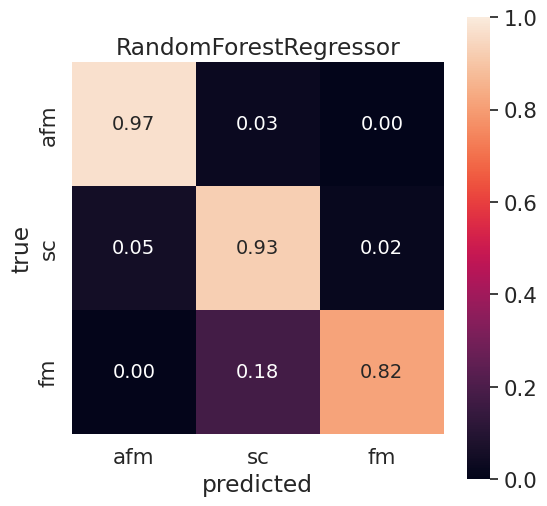

{'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.033972459714941665,
   'acc': np.float64(0.9041666666666668),
   'prec': 0.9041666666666667,
   'rec': 0.9041666666666667,
   'f1': 0.9041666666666667},
  array([[9.7069375e-01, 2.9231250e-02, 7.5000000e-05],
         [5.3918750e-02, 9.2557500e-01, 2.0506250e-02],
         [4.8500000e-03, 1.7891875e-01, 8.1623125e-01]]))}

In [26]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-2_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 05-3-2-3 Use contrastive Autoencoder and classifer on latent space (exclude FM)

In [27]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-21/version_1'
pc = PhaseClassification(save_path, pc_models, 43, mode)

In [ ]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/30 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

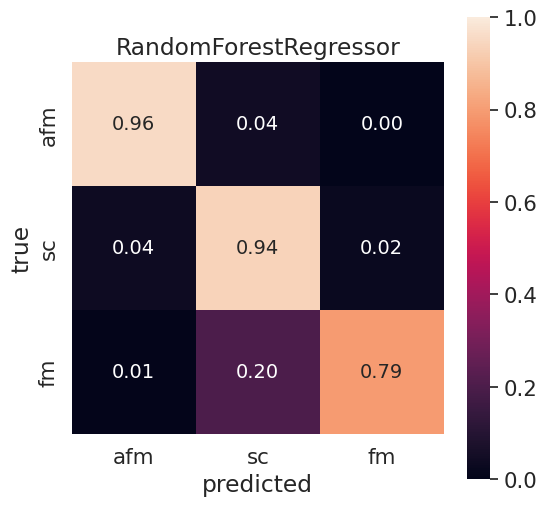

{'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.035589154308229926,
   'acc': np.float64(0.8956979166666666),
   'prec': 0.8956979166666666,
   'rec': 0.8956979166666666,
   'f1': 0.8956979166666666},
  array([[9.5648125e-01, 4.3450000e-02, 6.8750000e-05],
         [3.9006250e-02, 9.3658125e-01, 2.4412500e-02],
         [5.0562500e-03, 2.0091250e-01, 7.9403125e-01]]))}

In [29]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-3_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

# 0x U-Net

In [ ]:
info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
hidden_dims = [128, 64, 32]
config_kwargs = {'path_train': '../../../frgs_6d', 
                 'model_name': 'UNetVertex',
                 'hidden_dims': hidden_dims,
                 'epochs': 1000,
                 'sample_count_per_vertex': 2000, 
                 'test_ratio': 0.2, 
                 'subset': -1, 
                 'subset_shuffle': False, 
                 'devices': 'auto', 
                 'num_dataloader_workers': 8, 
                 'strategy': 'auto', 
                 'batch_size': 4096}


def init_trainer(device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    config_kwargs['device_type'] = device_type
    for k, v in kwargs.items():
        config_kwargs[k] = v
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                                config_kwargs=config_kwargs)
    return trainer

## train

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, hidden_dims)

## evaluate prediction

In [ ]:
test_file = 'tp0.020000_mu0.080000.h5'
test_file3d = '../../../frgs/' + test_file
test_file6d = '../../../frgs_6d/' + test_file

info = verteval.load_info_dict(info_fn)

vertex3 = AutoEncoderVertexDataset.load_from_file(test_file3d)
vertex6 = AutoEncoderVertex24x6Dataset.load_from_file(test_file6d)

keys = [f'n={x['latent_dim']}' for x in info]
trainer = init_trainer(device_type='cpu', batch_size=1024, num_dataloader_workers=8)

i = 18
axis = trainer.config.construction_axis
k, other_k = (axis + 1) // 2, 3
slice_idx_3d = i * 24 + i
nrows, ncols = 2, 3

### predict 24x24 slice

In [ ]:
# RESULTS FOR 2-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i, i, i), axis, keys, nrows, ncols, 
                             trainer.predict_slice2d, fixed_idcs=(i, i, i, i))

### predict 576x576 slice

In [ ]:
# RESULTS FOR 4-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i), (k, other_k), keys, nrows, ncols, 
                             trainer.predict_slice4d, fixed_idcs=(i, i), other_k=other_k)

### predict full vertex

In [ ]:
# RESULTS FOR 6-DIMENSIONAL PREDICTION
# for 6d-data
slice_at = (i, i, i, i)
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, slice_at, axis, keys, nrows, ncols, 
                             predict_func=trainer.predict)

In [ ]:
# for 3d-data
slice_at = slice_idx_3d
verteval.evaluate_and_report(info, test_file3d, trainer, vertex3, slice_at, axis, keys, nrows, ncols, 
                             load_func=trainer.load_prediction)

# ---